# 05 — แผนที่ PM2.5 ทั้งประเทศ และข้อจำกัด

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nattaponm/Teach_AOD_PM_PCD/blob/main/05_PM25_Mapping_and_Limitations.ipynb)

## จุดประสงค์การเรียนรู้

เมื่อจบ Notebook นี้ นิสิตสามารถ
1. นำแบบจำลอง Random Forest ไปใช้กับภาพ AOD เพื่อสร้าง **แผนที่ PM2.5** ความละเอียด 1 km
2. สรุปค่าเป็น **ค่าเฉลี่ยรายจังหวัด** ทั้ง 77 จังหวัด
3. ใช้ **residual** รายสถานีตรวจว่าแบบจำลองทำนายสูงหรือต่ำไปที่ใด
4. ระบุข้อจำกัดของแผนที่และเขียนรายงานผลอย่างซื่อตรง

**เวลาโดยประมาณ** 110 นาที

> **วิธีเรียน** — อ่านคำอธิบาย → รันทีละ cell → ดูผล → ตอบคำถาม "ลองคิด" ในใจก่อนรัน cell ถัดไป
> ไม่แนะนำให้กด *Run all* ในรอบแรก

## 1. หลักการ

### 1.1 จากแบบจำลองสู่แผนที่

แบบจำลองเรียนรู้ความสัมพันธ์จาก **สถานี** แล้วเรานำไปใช้กับ **ทุก pixel** ที่มีค่าตัวแปรทำนายครบ

```
ฝึก   : (AOD, WV, lat, lon, DOY) ที่สถานี  ──►  PM2.5 ที่วัดได้
ใช้   : (AOD, WV, lat, lon, DOY) ทุก pixel ──►  PM2.5 ที่ทำนาย
```

การทำนายในที่ที่ไม่มีสถานีคือการ **ประมาณค่านอกช่วงข้อมูลฝึก (extrapolation)** ยิ่ง pixel ต่างจากสภาพที่ตั้งสถานีมาก ยิ่งไม่แน่นอน

### 1.2 ค่าเฉลี่ยรายจังหวัด

$$\overline{PM}_{p} = \frac{1}{N_p}\sum_{i \in p} \widehat{PM}_i$$

โดย $N_p$ คือจำนวน pixel ที่มีค่าในจังหวัด $p$ ค่านี้เป็น **ค่าเฉลี่ยเชิงพื้นที่** ต่างจากค่าเฉลี่ยของสถานีซึ่งมักกระจุกในตัวเมือง

### 1.3 Residual — แบบจำลองพลาดไปทางใด

$$e_i = \hat{y}_i - y_i$$

$e > 0$ ทำนาย **สูงกว่า** ค่าจริง  $e < 0$ ทำนาย **ต่ำกว่า** ค่าจริง
ค่าเฉลี่ยของ $e$ รายสถานีเรียกว่า **mean bias** ถ้าสถานีใกล้กันมี bias ทิศเดียวกัน แสดงว่ายังมีปัจจัยเชิงพื้นที่ที่แบบจำลองไม่ได้จับ

### 1.4 ข้อตกลงที่ต้องรู้ก่อนเริ่ม

แบบจำลองฝึกจากข้อมูล **รายวัน** แต่ภาพที่เตรียมไว้เป็นค่าเฉลี่ย **รายเดือน** เราจึงป้อนค่าเฉลี่ยรายเดือนเข้าแบบจำลอง
เป็นการประมาณเพื่อการเรียน เพราะแบบจำลองไม่เป็นเส้นตรง

$$f(\overline{AOD}) \neq \overline{f(AOD)}$$

งานวิจัยจริงควรทำนายรายวันแล้วจึงเฉลี่ย

## 0. เตรียมเครื่องมือ

Cell ชุดนี้เหมือนกันทุก Notebook ทำ 3 อย่าง คือ โหลด library, ดาวน์โหลดข้อมูลจาก GitHub ของรายวิชา และสร้างฟังก์ชันแผนที่มาตรฐาน
รันทีละ cell ตามลำดับ ไม่จำเป็นต้องอ่านโค้ดส่วนนี้ละเอียดในรอบแรก

In [1]:
!pip -q install rasterio

In [2]:
from pathlib import Path
import urllib.request
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import rasterio
from rasterio.features import rasterize
from rasterio.plot import plotting_extent

warnings.filterwarnings("ignore")

YEAR = 2023
DATA_URL = "https://raw.githubusercontent.com/nattaponm/Teach_AOD_PM_PCD/main/data/"
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def fetch(name):
    # ดาวน์โหลดไฟล์จาก GitHub มาเก็บในโฟลเดอร์ data (โหลดครั้งเดียว)
    path = DATA_DIR / name
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL + name, path)
    return path

In [3]:
# รูปแบบภาพสำหรับงานตีพิมพ์: ตัวอักษรอ่านง่าย เส้นบาง ความละเอียด 300 dpi
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "legend.fontsize": 8, "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
})

UNIT = "µg m$^{-3}$"

def save_fig(fig, name):
    # บันทึกทั้ง PNG (ใส่รายงาน) และ PDF (ส่งวารสาร)
    fig.savefig(FIG_DIR / f"{name}.png")
    fig.savefig(FIG_DIR / f"{name}.pdf")
    print("บันทึกแล้ว:", FIG_DIR / f"{name}.png", "และ .pdf")

In [4]:
# ขอบเขต 77 จังหวัด และเส้นขอบประเทศ (รวมทุกจังหวัดเป็นรูปเดียว)
provinces = gpd.read_file(fetch("provinces.geojson"))
country = gpd.GeoSeries([provinces.buffer(0.002).union_all().buffer(-0.002)], crs=provinces.crs)

MAP_EXTENT = [97.0, 106.0, 5.3, 20.8]   # west, east, south, north

def base_map(ax, title=None, province_color="0.45"):
    # วาดองค์ประกอบแผนที่มาตรฐาน: จังหวัด ประเทศ พิกัด มาตราส่วน ทิศเหนือ
    provinces.boundary.plot(ax=ax, linewidth=0.25, color=province_color, zorder=3)
    country.boundary.plot(ax=ax, linewidth=0.9, color="black", zorder=4)

    ax.set_xlim(MAP_EXTENT[0], MAP_EXTENT[1]); ax.set_ylim(MAP_EXTENT[2], MAP_EXTENT[3])
    ax.set_aspect(1 / np.cos(np.deg2rad(13)))          # แก้การยืดของลองจิจูดที่ละติจูด ~13°N
    ax.set_xticks(np.arange(98, 107, 2)); ax.set_yticks(np.arange(6, 21, 2))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°E"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°N"))
    ax.tick_params(direction="in", top=True, right=True, length=3)
    ax.grid(linewidth=0.3, color="0.8", linestyle=":", zorder=0)

    # มาตราส่วน 200 km (1 องศาลองจิจูด = 111.32 x cos(ละติจูด) km)
    lat0, lon0 = 6.1, 102.9
    width = 200 / (111.32 * np.cos(np.deg2rad(lat0)))
    ax.plot([lon0, lon0 + width], [lat0, lat0], color="black", linewidth=1.5, zorder=5)
    ax.text(lon0 + width / 2, lat0 + 0.18, "200 km", ha="center", va="bottom", fontsize=7)

    # ลูกศรทิศเหนือ
    ax.annotate("N", xy=(105.2, 20.2), xytext=(105.2, 19.2), ha="center", va="center", fontsize=9,
                arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1))
    ax.set_xlabel(""); ax.set_ylabel("")              # พิกัดบอกอยู่ที่ตัวเลขแกนแล้ว
    if title:
        ax.set_title(title)
    return ax

print("จำนวนจังหวัด:", len(provinces))

จำนวนจังหวัด: 77


## 2. ฝึกแบบจำลองด้วยข้อมูลทั้งหมด

ใช้ตัวแปรและการตั้งค่าเดียวกับ Notebook 04 แต่ครั้งนี้ฝึกด้วยทุกคู่ข้อมูล เพราะจะนำไปใช้ทำแผนที่

In [5]:
m = pd.read_csv(fetch("aod_pm_matchup.csv"), parse_dates=["date"])
m["doy"] = m["date"].dt.dayofyear            # วันที่ของปี (1-365) แทนฤดูกาล

FEATURES = ["aod_055", "column_wv", "lat", "lon", "doy"]
MIN_PIXELS = 3

pairs = m.dropna(subset=["pm25"] + FEATURES)
pairs = pairs[pairs["aod_n_pixels"] >= MIN_PIXELS].reset_index(drop=True)

X = pairs[FEATURES]
y = pairs["pm25"]
groups = pairs["station"]                    # ใช้แบ่งข้อมูลแบบ "กันออกทั้งสถานี"

print("จำนวนคู่ข้อมูล:", len(pairs), "| สถานี:", groups.nunique())

จำนวนคู่ข้อมูล: 4147 | สถานี: 84


In [6]:
forest = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, n_jobs=-1, random_state=42)
forest.fit(X, y)
print("ฝึกแบบจำลองเสร็จ ใช้ตัวแปร:", FEATURES)

ฝึกแบบจำลองเสร็จ ใช้ตัวแปร: ['aod_055', 'column_wv', 'lat', 'lon', 'doy']


## 3. เตรียมกริดของ pixel

ภาพ `aod_2023_MM.tif` มี 3 แบนด์: AOD, Column WV และจำนวนวันที่มีข้อมูล
เราต้องรู้ lat/lon ของทุก pixel และรู้ว่า pixel ใดอยู่ในจังหวัดใด

In [7]:
with rasterio.open(fetch(f"aod_{YEAR}_03.tif")) as src:
    transform, shape = src.transform, (src.height, src.width)
    raster_extent = plotting_extent(src)

# พิกัดกึ่งกลางของทุก pixel
cols, rows = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
lon_grid, lat_grid = rasterio.transform.xy(transform, rows, cols)
lon_grid = np.asarray(lon_grid).reshape(shape); lat_grid = np.asarray(lat_grid).reshape(shape)

# แปลงขอบเขตจังหวัดเป็นกริด: แต่ละ pixel เก็บหมายเลขจังหวัด (0 = นอกประเทศไทย)
provinces = provinces.reset_index(drop=True)
province_grid = rasterize(
    [(geom, i + 1) for i, geom in enumerate(provinces.geometry)],
    out_shape=shape, transform=transform, fill=0, dtype="int16",
)
print("ขนาดกริด:", shape, "| pixel ในประเทศไทย:", int((province_grid > 0).sum()))

ขนาดกริด: (1789, 1003) | pixel ในประเทศไทย: 538522


## 4. ทำนาย PM2.5 ทุก pixel

ทำนายเฉพาะ pixel ที่ (1) อยู่ในประเทศไทย เพราะแบบจำลองฝึกจากสถานีในไทยเท่านั้น
และ (2) มีค่า AOD อย่างน้อย `MIN_DAYS` วันในเดือนนั้น เพื่อให้ค่าเฉลี่ยรายเดือนมีความหมาย

In [8]:
MIN_DAYS = 3
MONTH_NAMES = {2: "February", 3: "March", 4: "April"}

def predict_month(month, min_days=MIN_DAYS):
    # คืนค่ากริด PM2.5 ที่ทำนาย (NaN ในที่ที่ทำนายไม่ได้)
    with rasterio.open(fetch(f"aod_{YEAR}_{month:02d}.tif")) as src:
        aod, wv, n_days = src.read(1), src.read(2), src.read(3)

    usable = (province_grid > 0) & np.isfinite(aod) & np.isfinite(wv) & (np.nan_to_num(n_days) >= min_days)
    doy = pd.Timestamp(YEAR, month, 15).dayofyear        # ใช้กลางเดือนเป็นตัวแทน

    grid_X = pd.DataFrame({
        "aod_055": aod[usable], "column_wv": wv[usable],
        "lat": lat_grid[usable], "lon": lon_grid[usable], "doy": doy,
    })[FEATURES]

    out = np.full(shape, np.nan, dtype="float32")
    out[usable] = forest.predict(grid_X)
    return out

pm_maps = {month: predict_month(month) for month in [2, 3, 4]}
for month, grid in pm_maps.items():
    covered = np.isfinite(grid).sum() / (province_grid > 0).sum() * 100
    print(f"{MONTH_NAMES[month]:9s}: ทำนายได้ {covered:5.1f}% ของพื้นที่ประเทศ | ค่าเฉลี่ย {np.nanmean(grid):.1f} µg/m³")

February : ทำนายได้  90.5% ของพื้นที่ประเทศ | ค่าเฉลี่ย 47.2 µg/m³
March    : ทำนายได้  93.3% ของพื้นที่ประเทศ | ค่าเฉลี่ย 57.2 µg/m³
April    : ทำนายได้  93.2% ของพื้นที่ประเทศ | ค่าเฉลี่ย 64.1 µg/m³


### ภาพที่ 1 — แผนที่ PM2.5 รายเดือน

พื้นที่สีเทาคือ pixel ที่ทำนายไม่ได้เพราะ AOD ไม่พอ ไม่ได้แปลว่าอากาศสะอาด

บันทึกแล้ว: figures/fig12_pm25_maps_monthly.png และ .pdf


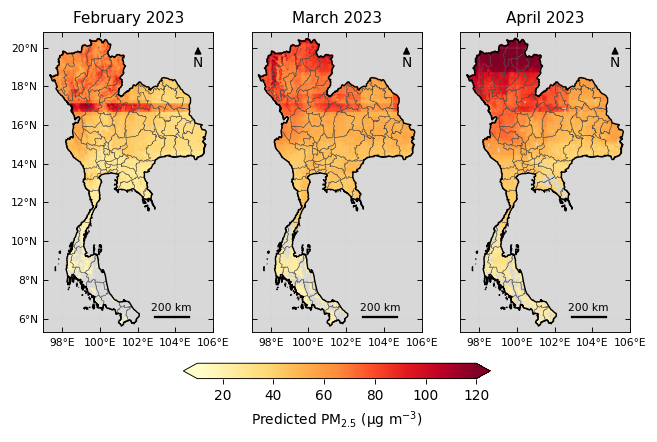

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 4.6), sharey=True)
cmap = plt.cm.YlOrRd.copy(); cmap.set_bad("0.85")

for ax, month in zip(axes, [2, 3, 4]):
    im = ax.imshow(np.ma.masked_invalid(pm_maps[month]), extent=raster_extent, cmap=cmap, vmin=10, vmax=120, zorder=1)
    base_map(ax, f"{MONTH_NAMES[month]} {YEAR}", province_color="0.3")
    ax.tick_params(labelsize=7)
fig.subplots_adjust(wspace=0.06)
fig.colorbar(im, ax=axes, orientation="horizontal", shrink=0.5, pad=0.08, extend="both",
             label=f"Predicted PM$_{{2.5}}$ ({UNIT})")
save_fig(fig, "fig12_pm25_maps_monthly")
plt.show()

> 💭 **ลองคิด** — รูปแบบเชิงพื้นที่เปลี่ยนจากกุมภาพันธ์ถึงเมษายนอย่างไร สอดคล้องกับข่าวและอนุกรมเวลาใน Notebook 01 หรือไม่

### บทเรียนจากแผนที่: แถบแนวนอนมาจากไหน

ดูแผนที่ให้ละเอียด จะเห็น **แถบตรงแนวนอน** พาดข้ามประเทศที่ละติจูดประมาณ 17°N ฝุ่นจริงไม่กระจายตัวเป็นเส้นตรงตามเส้นละติจูด
แถบนี้จึงเป็น **ร่องรอยของแบบจำลอง (model artifact)** ไม่ใช่ลักษณะของฝุ่น สาเหตุมีสองข้อประกอบกัน

1. เราใส่ `lat` เป็นตัวแปรทำนาย และ Notebook 04 พบว่ามีความสำคัญรองจาก AOD
2. ต้นไม้ตัดสินใจแบ่งข้อมูลด้วยคำถามแบบ "lat > 17.0 หรือไม่" ค่าทำนายจึงเปลี่ยนเป็น **ขั้นบันได** เมื่อข้ามเส้นนั้น

```
สถานีทางเหนือของเส้น  →  ค่าสูง (ควันไฟ)      แบบจำลองจำว่า "เหนือเส้นนี้ = ค่าสูง"
สถานีทางใต้ของเส้น    →  ค่าต่ำกว่า            แล้วใช้กฎนี้กับทุก pixel แม้ไม่มีสถานีอยู่ใกล้
```

ตัวเลข $R^2$ บอกเรื่องนี้ไม่ได้ ต้อง **ดูแผนที่ด้วยตา** เสมอ นิสิตจะได้ลองแก้ปัญหานี้ในแบบฝึกหัดข้อ 4

## 5. ค่าเฉลี่ยรายจังหวัด

ใช้ `province_grid` จัดกลุ่ม pixel ตามจังหวัด แล้วหาค่าเฉลี่ยและสัดส่วนพื้นที่ที่มีค่า (coverage)

In [10]:
def province_summary(grid):
    inside = province_grid > 0
    table = pd.DataFrame({"pid": province_grid[inside], "pm": grid[inside].astype("float64")})
    out = table.groupby("pid")["pm"].agg(pm25_mean="mean", coverage=lambda s: s.notna().mean() * 100)
    return provinces[["prov_en", "prov_th", "region"]].join(out.set_axis(out.index - 1))

summary_march = province_summary(pm_maps[3])
summary_march.sort_values("pm25_mean", ascending=False).head(10).round(1)

,prov_en,prov_th,region,pm25_mean,coverage
75,Mae Hong Son,แม่ฮ่องสอน,North,87.9,100.0
1,Chiang Rai,เชียงราย,North,85.1,100.0
0,Phayao,พะเยา,North,83.3,100.0
3,Nan,น่าน,North,82.7,100.0
67,Chiang Mai,เชียงใหม่,North,78.3,100.0
39,Loei,เลย,Northeast,74.9,100.0
4,Tak,ตาก,West,73.3,99.7
21,Nong Bua Lamphu,หนองบัวลำภู,Northeast,73.3,99.7
10,Phitsanulok,พิษณุโลก,Central,72.9,99.6
66,Uttaradit,อุตรดิตถ์,North,70.7,100.0


### ภาพที่ 2 — แผนที่ค่าเฉลี่ยรายจังหวัด เดือนมีนาคม

จังหวัดที่ coverage ต่ำกว่า 50% ถูกแรเงา เพราะค่าเฉลี่ยมาจากพื้นที่ไม่ถึงครึ่งจังหวัด

บันทึกแล้ว: figures/fig13_province_mean_march.png และ .pdf


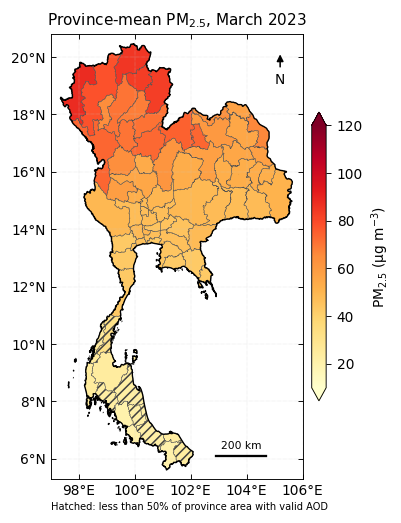

In [11]:
choropleth = provinces.join(summary_march[["pm25_mean", "coverage"]])

fig, ax = plt.subplots(figsize=(3.6, 6.2))
choropleth.plot(ax=ax, column="pm25_mean", cmap="YlOrRd", vmin=10, vmax=120, zorder=1,
                missing_kwds={"color": "0.85"})
low = choropleth[choropleth["coverage"] < 50]
if len(low):
    low.plot(ax=ax, facecolor="none", edgecolor="0.25", hatch="////", linewidth=0, zorder=2)
base_map(ax, f"Province-mean PM$_{{2.5}}$, March {YEAR}", province_color="0.3")
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(10, 120))
fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.03, extend="both", label=f"PM$_{{2.5}}$ ({UNIT})")
ax.text(0, -0.07, "Hatched: less than 50% of province area with valid AOD", transform=ax.transAxes, fontsize=6.5)
save_fig(fig, "fig13_province_mean_march")
plt.show()

## 6. ตรวจแบบจำลองด้วย residual รายสถานี

ใช้ค่าทำนายแบบกันสถานี (เหมือน Notebook 04) เพื่อให้ residual สะท้อนการทำนายในที่ที่ไม่เคยเห็น

### ภาพที่ 3 — แผนที่ mean bias รายสถานี

บันทึกแล้ว: figures/fig14_station_bias_map.png และ .pdf


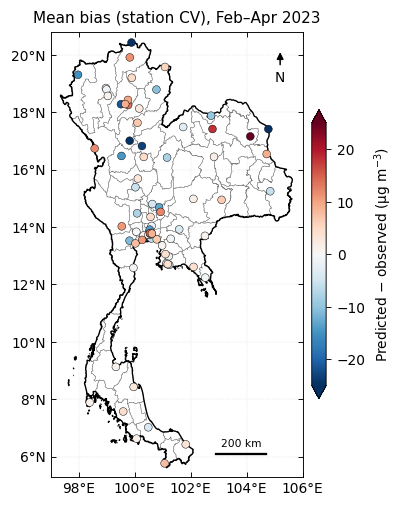

R² แบบกันสถานี = 0.69 | RMSE = 22.8 µg/m³


In [12]:
cv_pred = cross_val_predict(forest, X, y, cv=GroupKFold(n_splits=5), groups=groups)

resid = pairs[["station", "lat", "lon", "region"]].copy()
resid["residual"] = cv_pred - y
bias = resid.groupby(["station", "lat", "lon", "region"])["residual"].agg(["mean", "size"]).reset_index()
bias = bias[bias["size"] >= 10]

vmax = np.ceil(np.percentile(np.abs(bias["mean"]), 95) / 5) * 5
fig, ax = plt.subplots(figsize=(3.6, 6.2))
base_map(ax, f"Mean bias (station CV), Feb–Apr {YEAR}")
sc = ax.scatter(bias["lon"], bias["lat"], c=bias["mean"], cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                s=26, edgecolor="black", linewidth=0.3, zorder=6)
fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.03, extend="both", label=f"Predicted − observed ({UNIT})")
save_fig(fig, "fig14_station_bias_map")
plt.show()

print(f"R² แบบกันสถานี = {r2_score(y, cv_pred):.2f} | RMSE = {np.sqrt(mean_squared_error(y, cv_pred)):.1f} µg/m³")

> 💭 **ลองคิด** — สถานีสีแดง (ทำนายสูงไป) และสีน้ำเงิน (ทำนายต่ำไป) กระจายสุ่มหรือรวมกลุ่มตามภาค

## 7. ข้อจำกัดที่ต้องเขียนในรายงานเสมอ

```
แผนที่ที่ดูสวย              ≠  แผนที่ที่ถูกต้อง
แถบตรงหรือขอบคมในแผนที่     =  ร่องรอยของแบบจำลอง ไม่ใช่ลักษณะของฝุ่น
พื้นที่ไม่มีค่า (สีเทา)       ≠  อากาศสะอาด
ค่าทำนายบนภูเขาและป่า       =  extrapolation จากสถานีในเมือง
ค่าเฉลี่ยรายเดือนจากดาวเทียม  =  ค่าเฉลี่ยของ "วันที่ฟ้าเปิด" เท่านั้น
แบบจำลองปี 2023             ≠  ใช้กับปีอื่นได้โดยไม่ทดสอบ
```

แผนที่นี้เหมาะกับการดู **รูปแบบเชิงพื้นที่โดยรวม** ยังไม่เหมาะกับการตัดสินว่าตำบลใดเกินมาตรฐาน

## 8. ทบทวนทั้งชุดบทเรียน

| Notebook | คำถาม | สิ่งที่ได้ |
|---|---|---|
| 01 | AOD และ PM2.5 คืออะไร | สองตัวแปรวัดคนละสิ่ง คนละระดับความสูง |
| 02 | จับคู่อย่างไร ข้อมูลหายเท่าใด | ชุดคู่ข้อมูลและความเข้าใจเรื่อง sampling bias |
| 03 | สัมพันธ์กันแค่ไหน | $r$, เส้นถดถอย และความต่างระหว่างภาค |
| 04 | Machine learning ช่วยได้เท่าใด | Random Forest และการทดสอบแบบกันสถานี |
| 05 | ทำแผนที่ได้หรือไม่ เชื่อได้แค่ไหน | แผนที่ PM2.5 พร้อมข้อจำกัด |

---
## แบบฝึกหัด

### ข้อ 1 (ฝึกทำ) — แผนที่ของเดือนที่เลือก
สร้างแผนที่ PM2.5 เดือนเมษายนแบบแผ่นเดียว โดยใช้ `base_map` และบันทึกด้วย `save_fig`

In [13]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: ดูโค้ดภาพที่ 1 แล้วใช้ fig, ax = plt.subplots(figsize=(3.6, 6.2)) กับ pm_maps[4]

บันทึกแล้ว: figures/exercise_pm25_april.png และ .pdf


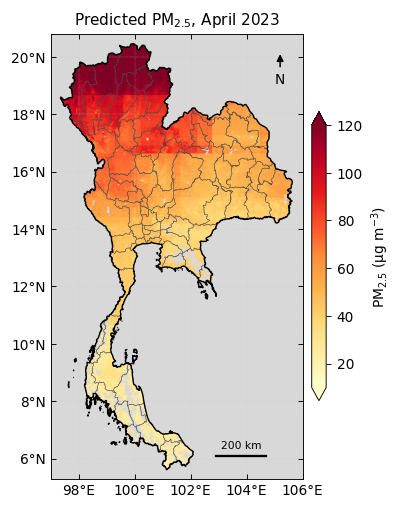

In [14]:
#@title เฉลยข้อ 1 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
fig, ax = plt.subplots(figsize=(3.6, 6.2))
im = ax.imshow(np.ma.masked_invalid(pm_maps[4]), extent=raster_extent, cmap=cmap, vmin=10, vmax=120, zorder=1)
base_map(ax, f"Predicted PM$_{{2.5}}$, April {YEAR}", province_color="0.3")
fig.colorbar(im, ax=ax, shrink=0.55, pad=0.03, extend="both", label=f"PM$_{{2.5}}$ ({UNIT})")
save_fig(fig, "exercise_pm25_april")
plt.show()

### ข้อ 2 (ฝึกคิด) — 10 จังหวัดสูงสุดเดือนเมษายน
ใช้ฟังก์ชัน `province_summary` หา 10 จังหวัดที่ค่าเฉลี่ยทำนายสูงสุดในเดือนเมษายน โดยนับเฉพาะจังหวัดที่ coverage อย่างน้อย 50%

In [15]:
# เขียนโค้ดของคุณที่นี่

my_top_province = None    # ใส่ชื่อจังหวัดอันดับ 1 เป็นภาษาอังกฤษตามคอลัมน์ prov_en

In [16]:
#@title ตรวจคำตอบข้อ 2 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
_s = province_summary(pm_maps[4]); _s = _s[_s["coverage"] >= 50]
_expected = _s.sort_values("pm25_mean", ascending=False)["prov_en"].iloc[0]
if my_top_province is None:
    print("ยังไม่ได้ใส่คำตอบใน my_top_province")
elif str(my_top_province).strip().lower() == _expected.lower():
    print("ถูกต้อง")
else:
    print("ยังไม่ใช่ ตรวจว่ากรอง coverage >= 50 ก่อนเรียงลำดับ และใช้ข้อมูลเดือนเมษายน (pm_maps[4])")

ยังไม่ได้ใส่คำตอบใน my_top_province


In [17]:
#@title เฉลยข้อ 2 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
summary_april = province_summary(pm_maps[4])
summary_april[summary_april["coverage"] >= 50].sort_values("pm25_mean", ascending=False).head(10).round(1)

,prov_en,prov_th,region,pm25_mean,coverage
1,Chiang Rai,เชียงราย,North,137.1,100.0
0,Phayao,พะเยา,North,126.0,100.0
75,Mae Hong Son,แม่ฮ่องสอน,North,112.5,100.0
3,Nan,น่าน,North,111.7,100.0
67,Chiang Mai,เชียงใหม่,North,109.3,100.0
65,Lampang,ลำปาง,North,99.9,100.0
68,Lamphun,ลำพูน,North,93.8,100.0
2,Phrae,แพร่,North,87.1,100.0
66,Uttaradit,อุตรดิตถ์,North,82.3,99.7
10,Phitsanulok,พิษณุโลก,Central,82.2,99.4


### ข้อ 3 (ฝึกคิด) — เกณฑ์จำนวนวันกับพื้นที่ที่ทำนายได้
คำนวณร้อยละของพื้นที่ประเทศที่ทำนายได้ในเดือนมีนาคม เมื่อ `min_days` เท่ากับ 1, 3, 5 และ 10

In [18]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: เรียก predict_month(3, min_days=k) แล้วนับ pixel ที่ไม่ใช่ NaN เทียบกับ (province_grid > 0).sum()

In [19]:
#@title เฉลยข้อ 3 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
n_thailand = (province_grid > 0).sum()
for k in [1, 3, 5, 10]:
    grid = predict_month(3, min_days=k)
    print(f"อย่างน้อย {k:2d} วัน: ทำนายได้ {np.isfinite(grid).sum() / n_thailand * 100:5.1f}% | ค่าเฉลี่ย {np.nanmean(grid):.1f} µg/m³")

อย่างน้อย  1 วัน: ทำนายได้  98.0% | ค่าเฉลี่ย 55.6 µg/m³
อย่างน้อย  3 วัน: ทำนายได้  93.3% | ค่าเฉลี่ย 57.2 µg/m³
อย่างน้อย  5 วัน: ทำนายได้  90.0% | ค่าเฉลี่ย 58.3 µg/m³
อย่างน้อย 10 วัน: ทำนายได้  83.2% | ค่าเฉลี่ย 60.4 µg/m³


<details>
<summary><b>คำอธิบายข้อ 3</b> (คลิกเพื่อเปิด)</summary>

เกณฑ์เข้มขึ้น พื้นที่ที่ทำนายได้ลดลง แต่ค่าเฉลี่ยรายเดือนของแต่ละ pixel น่าเชื่อถือขึ้น
ให้สังเกตด้วยว่าค่าเฉลี่ยทั้งประเทศเปลี่ยนหรือไม่ ถ้าเปลี่ยน แสดงว่า pixel ที่ถูกตัดออกไม่ได้สุ่ม
แต่เป็นพื้นที่เฉพาะ (เช่น ภูเขาที่มีเมฆหรือควันหนาบ่อย) ซึ่งเป็น sampling bias แบบเดียวกับ Notebook 02 ในมิติพื้นที่

</details>

### ข้อ 4 (ฝึกคิด) — ลบแถบแนวนอนออกจากแผนที่
ฝึก Random Forest ใหม่โดย **ไม่ใช้ lat และ lon** แล้วทำแผนที่เดือนมีนาคมเทียบกับแผนที่เดิมแบบสองภาพคู่กัน
พร้อมเทียบ $R^2$ แบบกันสถานีของแบบจำลองทั้งสอง

In [20]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: 1) features_no_loc = ["aod_055", "column_wv", "doy"]
#         2) ฝึก RandomForestRegressor ตัวใหม่ด้วย X[features_no_loc]
#         3) ดูโค้ดในฟังก์ชัน predict_month แล้วทำนายเดือนมีนาคมด้วยตัวแปร 3 ตัวนี้
#         4) วาดสองแผนที่ด้วย plt.subplots(1, 2) และ base_map

บันทึกแล้ว: figures/exercise_map_with_without_location.png และ .pdf


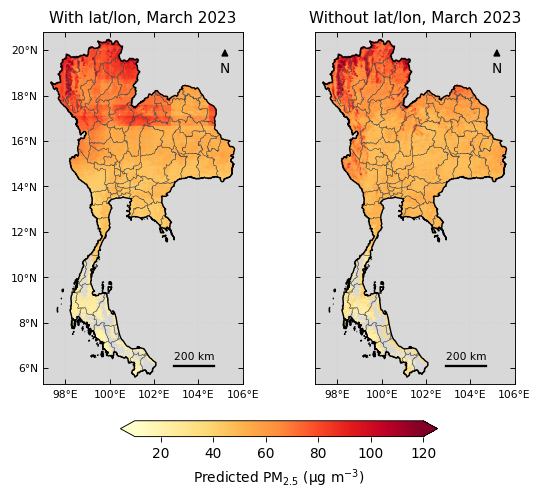

มี lat/lon    : R² แบบกันสถานี = 0.69 | RMSE = 22.8 µg/m³
ไม่มี lat/lon : R² แบบกันสถานี = 0.60 | RMSE = 25.7 µg/m³


In [21]:
#@title เฉลยข้อ 4 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
features_no_loc = ["aod_055", "column_wv", "doy"]
forest_no_loc = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, n_jobs=-1, random_state=42)
forest_no_loc.fit(X[features_no_loc], y)

# ทำนายเดือนมีนาคมด้วยตัวแปร 3 ตัว (ขั้นตอนเดียวกับ predict_month)
with rasterio.open(fetch(f"aod_{YEAR}_03.tif")) as src:
    aod, wv, n_days = src.read(1), src.read(2), src.read(3)
usable = (province_grid > 0) & np.isfinite(aod) & np.isfinite(wv) & (np.nan_to_num(n_days) >= MIN_DAYS)
grid_X = pd.DataFrame({"aod_055": aod[usable], "column_wv": wv[usable],
                       "doy": pd.Timestamp(YEAR, 3, 15).dayofyear})[features_no_loc]
pm_no_loc = np.full(shape, np.nan, dtype="float32")
pm_no_loc[usable] = forest_no_loc.predict(grid_X)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 5.4), sharey=True)
for ax, grid, title in [(axes[0], pm_maps[3], "With lat/lon"), (axes[1], pm_no_loc, "Without lat/lon")]:
    im = ax.imshow(np.ma.masked_invalid(grid), extent=raster_extent, cmap=cmap, vmin=10, vmax=120, zorder=1)
    base_map(ax, f"{title}, March {YEAR}", province_color="0.3")
    ax.tick_params(labelsize=7)
fig.subplots_adjust(wspace=0.06)
fig.colorbar(im, ax=axes, orientation="horizontal", shrink=0.6, pad=0.08, extend="both",
             label=f"Predicted PM$_{{2.5}}$ ({UNIT})")
save_fig(fig, "exercise_map_with_without_location")
plt.show()

cv = GroupKFold(n_splits=5)
for label, cols in [("มี lat/lon", FEATURES), ("ไม่มี lat/lon", features_no_loc)]:
    p = cross_val_predict(forest, X[cols], y, cv=cv, groups=groups)
    print(f"{label:14s}: R² แบบกันสถานี = {r2_score(y, p):.2f} | RMSE = {np.sqrt(mean_squared_error(y, p)):.1f} µg/m³")

<details>
<summary><b>คำอธิบายข้อ 4</b> (คลิกเพื่อเปิด)</summary>

แผนที่ที่ไม่ใช้พิกัดจะไม่มีแถบแนวนอน เพราะค่าทำนายขึ้นกับสิ่งที่ดาวเทียมวัดได้ในแต่ละ pixel เท่านั้น รูปแบบเชิงพื้นที่จึงตาม AOD

ให้เทียบสองอย่างพร้อมกัน คือ **หน้าตาของแผนที่** และ **ตัวเลขความแม่นยำ** แล้วถามว่าได้อะไรและเสียอะไร
- ถ้า $R^2$ ลดลงมาก แสดงว่าพิกัดกำลังทำหน้าที่แทนปัจจัยจริงที่เราไม่ได้ใส่ เช่น ความสูงชั้นขอบเขตบรรยากาศ ชนิดของแหล่งกำเนิด และภูมิประเทศ
- ทางแก้ที่ดีกว่าการเลือกข้างใดข้างหนึ่ง คือ **ใส่ปัจจัยจริงเหล่านั้นเป็นตัวแปร** ซึ่งเปลี่ยนแปลงอย่างต่อเนื่องในพื้นที่ แทนการใช้พิกัด

นี่คือเหตุผลที่งานวิจัยใช้ตัวแปรอุตุนิยมวิทยาและการใช้ที่ดิน และเป็นตัวอย่างว่าการเลือกแบบจำลองต้องดูทั้งตัวเลขและความสมเหตุสมผลทางกายภาพ

</details>

### ข้อ 5 (ฝึกตีความ)
ดูภาพที่ 1 ร่วมกับแผนที่สถานีใน Notebook 01 ให้ระบุพื้นที่ 2 แห่งที่นิสิต **ไม่ควรเชื่อ** ค่าบนแผนที่มากนัก พร้อมเหตุผล

<details>
<summary><b>แนวคำตอบข้อ 5</b> (คลิกเพื่อเปิด)</summary>

คำตอบที่เหมาะสม เช่น
1. **พื้นที่ภูเขาและป่าตามแนวชายแดนตะวันตกและเหนือ** — แทบไม่มีสถานี (สถานีอยู่ในตัวเมืองและหุบเขา) แบบจำลองจึงต้อง extrapolate
   ทั้งที่เป็นบริเวณใกล้แหล่งไฟป่าซึ่งความสัมพันธ์ AOD–PM2.5 อาจต่างจากในเมือง
2. **ภาคใต้ตอนล่าง** — สถานีน้อย ค่า PM2.5 ต่ำกว่าช่วงค่าส่วนใหญ่ในข้อมูลฝึก และเมฆมากทำให้ AOD มีน้อยวัน
3. **บริเวณที่ coverage ต่ำหรือ pixel กระจัดกระจาย** — ค่าเฉลี่ยรายเดือนมาจากไม่กี่วัน
4. **ชายฝั่งและแหล่งน้ำขนาดใหญ่** — MAIAC เป็นผลิตภัณฑ์สำหรับพื้นดิน ค่าใกล้ขอบน้ำมีความไม่แน่นอนสูง

หลักคิดร่วมกันคือ ถามเสมอว่า "ในชุดฝึกมีตัวอย่างที่คล้าย pixel นี้หรือไม่"

</details>

### ต่อยอดสำหรับ ป.โท — จากบทเรียนสู่งานวิจัย
เขียนโครงร่างวิธีวิจัยหนึ่งหน้า สำหรับยกระดับงานนี้ให้ตีพิมพ์ได้ โดยครอบคลุมอย่างน้อย 4 ประเด็น

*แนวทาง*
1. **ข้อมูล** — ขยายเป็น 2021–2025 และทดสอบข้ามปี (ฝึกด้วย 4 ปี ทดสอบปีที่เหลือ)
2. **ตัวแปร** — เพิ่มอุตุนิยมวิทยาจาก ERA5 จุดความร้อน (FIRMS) ความสูงภูมิประเทศ และการใช้ที่ดิน แทนการใช้พิกัด (ดูแนวทางของ Bagheri, 2022 ใน Notebook 04)
3. **การทำนาย** — ทำนายรายวันแล้วจึงเฉลี่ย และเติมช่องว่างของ AOD (gap-filling)
4. **การทดสอบ** — ใช้ spatial block cross-validation รายงาน $R^2$, RMSE, MAE และ bias แยกรายภาคและรายช่วงความเข้มข้น
5. **ความไม่แน่นอน** — แสดงแผนที่ความไม่แน่นอนคู่กับแผนที่ค่าทำนาย เช่น ส่วนเบี่ยงเบนมาตรฐานระหว่างต้นไม้ใน forest